# OP3 analysis — well noise, position effects and shared-well coordination in a second dataset

**Data:** OP3 (Open Problems perturbation dataset, GSE279945): PBMCs from 3 donors, 6 plates (2 per donor), 144 compounds, 24 h. Each plate has 8 DMSO wells (column 3, rows A-H) and 8 wells each of two positive controls (belinostat column 1, dabrafenib column 2); compounds occupy columns 4-12. Downloaded with `op3_download.ipynb`.

**Tests (repeating Parse-only findings in an independent dataset):**
1. **Well-to-well noise:** two halves of one DMSO well vs halves of two different DMSO wells (as with the PBS wells in Parse).
2. **Shared-well coordination:** a pseudo-response between two DMSO wells (no treatment difference) is computed per cell type. If cell types of the *same* well pair correlate more than cell types of *different* well pairs, well-level effects alone create cross-cell-type coordination, the mechanism behind the audit of Zahid (2026).
3. **Position effects:** all controls sit in columns 1-3. Does the component shared by all compound responses change with column (distance from the control column) or with edge rows (A, H)?

In [1]:
import os
import numpy as np, pandas as pd, scipy.sparse as sp
import anndata as ad
from scipy.stats import spearmanr, rankdata
from itertools import combinations
import matplotlib.pyplot as plt, seaborn as sns

OP3_FILE = "data/op3/sc_counts_reannotated_with_counts.h5ad"
CACHE_DIR = "data/op3/cache"
RESULTS_DIR = "results/op3_audit"
for d in [CACHE_DIR, RESULTS_DIR]: os.makedirs(d, exist_ok=True)

DMSO = "Dimethyl Sulfoxide"
CELL_TYPES = ["T cells", "B cells", "Myeloid cells", "NK cells"]
MIN_CELLS_HALF = 20
N_GENES = 2000
TARGET = 1e4
CHUNK = 50_000
SEED = 0

## 1. Pseudobulk per plate x well x cell type x random half (cached)

In [2]:
F_PB = os.path.join(CACHE_DIR, "pb_well.npz")
import h5py
a = ad.read_h5ad(OP3_FILE, backed="r")
obs = a.obs[["plate_name", "well", "row", "col", "donor_id", "sm_name", "cell_type"]].copy()
# raw UMI counts are stored in raw/X (X itself is log-normalized); read the CSR arrays directly
H5 = h5py.File(OP3_FILE, "r")
RAW = H5["raw/X"]; INDPTR = RAW["indptr"][:]
N_OBS, N_VARS = (int(v) for v in RAW.attrs["shape"])           # matrix shape stored with the CSR arrays
def raw_rows(s, e):
    lo, hi = INDPTR[s], INDPTR[e]
    return sp.csr_matrix((RAW["data"][lo:hi], RAW["indices"][lo:hi], INDPTR[s:e + 1] - lo), shape=(e - s, N_VARS))
x0 = raw_rows(0, 200).toarray()
print(f"raw counts: {N_OBS:,} cells x {N_VARS:,} genes | integer: {bool(np.allclose(x0, np.round(x0)))} | max: {x0.max()}")

if os.path.exists(F_PB):
    z = np.load(F_PB, allow_pickle=True)
    SUMS = z["sums"]; PB = pd.DataFrame(z["meta"].tolist(), columns=["plate", "well", "cell_type", "half", "n_cells"])
    print("loaded cache", SUMS.shape)
else:
    half = np.random.default_rng(SEED).integers(0, 2, N_OBS)
    key = pd.Series(list(zip(obs.plate_name.astype(str), obs.well.astype(str), obs.cell_type.astype(str), half)))
    code_, uniq = pd.factorize(key)
    SUMS = np.zeros((len(uniq), N_VARS), np.float32)
    for s in range(0, N_OBS, CHUNK):
        e = min(s + CHUNK, N_OBS)
        X = raw_rows(s, e)
        G = sp.csr_matrix((np.ones(e - s, np.float32), (code_[s:e], np.arange(e - s))), shape=(len(uniq), e - s))
        SUMS += (G @ X).toarray().astype(np.float32)
        print(f"\r{e:,}/{N_OBS:,}", end="")
    PB = pd.DataFrame(list(uniq), columns=["plate", "well", "cell_type", "half"])
    PB["n_cells"] = np.bincount(code_, minlength=len(uniq))
    np.savez(F_PB, sums=SUMS, meta=PB.to_numpy(dtype=object))
    print("\ncached", SUMS.shape)

WELLS = (obs.groupby(["plate_name", "well"], observed=True)
         .agg(row=("row", "first"), col=("col", "first"), donor=("donor_id", "first"), compound=("sm_name", "first"))
         .reset_index().rename(columns={"plate_name": "plate"}))
WELLS["plate"] = WELLS.plate.astype(str); WELLS["well"] = WELLS.well.astype(str)
WELLS["row"] = WELLS.row.astype(str); WELLS["col"] = WELLS.col.astype(int); WELLS["compound"] = WELLS.compound.astype(str)
IDX = {(r.plate, r.well, r.cell_type, int(r.half)): (i, r.n_cells) for i, r in PB.iterrows()}

def lognorm(x): return np.log1p(x / max(x.sum(), 1) * TARGET)
GIDX = np.argsort(lognorm(SUMS.sum(0)))[::-1][:N_GENES]
def prof(plate, well, ct, h=None):
    hs = [0, 1] if h is None else [h]
    got = [IDX.get((plate, well, ct, hh)) for hh in hs]
    if any(g is None for g in got) or sum(g[1] for g in got) < MIN_CELLS_HALF * len(hs): return None
    return lognorm(sum(SUMS[g[0]].astype(np.float64) for g in got))[GIDX]
PLATES = sorted(WELLS.plate.unique())
print(WELLS.groupby("plate").donor.first())

raw counts: 298,087 cells x 21,265 genes | integer: True | max: 1473.0
298,087/298,087
cached (4489, 21265)
plate
NeurIPS2023-010    Donor 1
NeurIPS2023-011    Donor 1
NeurIPS2023-012    Donor 2
NeurIPS2023-013    Donor 2
NeurIPS2023-014    Donor 3
NeurIPS2023-015    Donor 3
Name: donor, dtype: category
Categories (3, str): ['Donor 1', 'Donor 2', 'Donor 3']


## 2. Well-to-well noise in DMSO wells

In [3]:
rows = []
for plate in PLATES:
    dm = WELLS[(WELLS.plate == plate) & (WELLS.compound == DMSO)].well.tolist()
    for ct in CELL_TYPES:
        P = {w: (prof(plate, w, ct, 0), prof(plate, w, ct, 1)) for w in dm}
        P = {w: v for w, v in P.items() if v[0] is not None and v[1] is not None}
        if len(P) < 3: continue
        within = np.mean([np.sum((A - B) ** 2) for A, B in P.values()])
        between = np.mean([np.sum((P[w][0] - P[v][1]) ** 2) for w in P for v in P if v != w])
        rows.append(dict(plate=plate, cell_type=ct, n_wells=len(P), ratio=between / within,
                         well_noise_frac=(between - within) / between))
WELLNOISE = pd.DataFrame(rows)
WELLNOISE.to_csv(f"{RESULTS_DIR}/dmso_well_noise.csv", index=False)
WN = WELLNOISE.groupby("cell_type")[["n_wells", "ratio", "well_noise_frac"]].median().round(3)
WN.to_csv(f"{RESULTS_DIR}/dmso_well_noise_summary.csv")
WN

,n_wells,ratio,well_noise_frac
cell_type,,,
B cells,8.0,1.470,0.319
Myeloid cells,8.0,3.197,0.687
NK cells,4.0,1.207,0.171
T cells,8.0,3.005,0.667


## 3. Shared-well coordination from DMSO-vs-DMSO pseudo-responses
For every pair of DMSO wells (i, j) on a plate, pseudo-response(cell type) = profile(i) - profile(j): no treatment difference at all. **Same pair:** Spearman between two cell types of the same well pair. **Null:** the same two cell types taken from two disjoint well pairs of the same plate. If same-pair correlation exceeds the null, effects shared by all cell types of a well create cross-cell-type coordination.

In [4]:
def zr(v): r = rankdata(v); r = r - r.mean(); return r / np.linalg.norm(r)
rng = np.random.default_rng(SEED)
rows = []
for plate in PLATES:
    dm = WELLS[(WELLS.plate == plate) & (WELLS.compound == DMSO)].well.tolist()
    pairs = list(combinations(sorted(dm), 2))
    for a_ct, b_ct in combinations(CELL_TYPES, 2):
        Z = {}
        for (i, j) in pairs:
            pa = [prof(plate, i, a_ct), prof(plate, j, a_ct)]; pb = [prof(plate, i, b_ct), prof(plate, j, b_ct)]
            if any(v is None for v in pa + pb): continue
            Z[(i, j)] = (zr(pa[0] - pa[1]), zr(pb[0] - pb[1]))
        keys = list(Z)
        if len(keys) < 6: continue
        same = [Z[k][0] @ Z[k][1] for k in keys]
        disjoint = [(k1, k2) for k1 in keys for k2 in keys if not set(k1) & set(k2)]
        null = [Z[k1][0] @ Z[k2][1] for k1, k2 in disjoint]
        rows.append(dict(plate=plate, pair=f"{a_ct} / {b_ct}", same_pair=np.median(same), different_pairs=np.median(null)))
COORD = pd.DataFrame(rows)
COORD["excess"] = COORD.same_pair - COORD.different_pairs
COORD.to_csv(f"{RESULTS_DIR}/dmso_shared_well_coordination.csv", index=False)
print("median same-pair:", COORD.same_pair.median().round(3), "| median different pairs:", COORD.different_pairs.median().round(3),
      "| excess > 0 in", f"{(COORD.excess > 0).mean():.0%}", "of plate x cell-type-pair combinations")
COORD.groupby("pair")[["same_pair", "different_pairs", "excess"]].median().round(3)

median same-pair: 0.211 | median different pairs: -0.006 | excess > 0 in 100% of plate x cell-type-pair combinations


,same_pair,different_pairs,excess
pair,,,
B cells / Myeloid cells,0.220,-0.006,0.217
B cells / NK cells,0.162,-0.019,0.184
Myeloid cells / NK cells,0.165,-0.021,0.161
T cells / B cells,0.291,0.007,0.275
T cells / Myeloid cells,0.255,-0.005,0.260
T cells / NK cells,0.228,-0.015,0.220


## 4. Position effects
Responses of compound wells are computed against the plate's DMSO mean, per cell type. The component shared by all compounds on a plate (their mean response) is the analog of the shared axis. For each compound well, its **projection on that shared component** is related to its column (4-12, distance from the control column) and to edge rows (A, H). DMSO wells alone are also checked: are edge-row DMSO wells further from the DMSO mean than interior ones?

,rho_col,edge_minus_interior,sd_shared
cell_type,,,
B cells,0.033,-0.637,2.463
Myeloid cells,0.265,-0.309,2.220
NK cells,0.020,-1.288,1.984
T cells,0.047,-0.596,2.333


DMSO wells, distance to plate DMSO mean (edge rows A/H vs interior):


edge_row,False,True
cell_type,,
B cells,4.599,4.615
Myeloid cells,3.948,4.533
NK cells,5.872,6.180
T cells,3.137,3.703


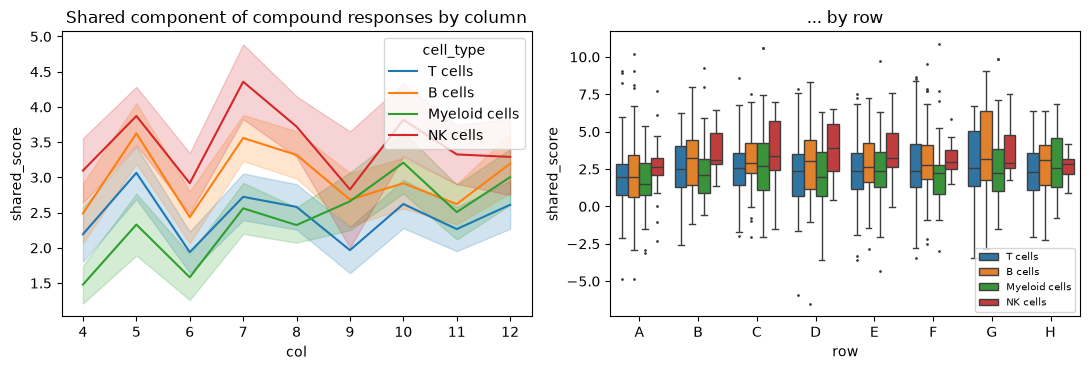

In [5]:
rows, dmso_rows = [], []
for plate in PLATES:
    W = WELLS[WELLS.plate == plate]
    dm = W[W.compound == DMSO].well.tolist()
    for ct in CELL_TYPES:
        dprof = {w: prof(plate, w, ct) for w in dm}; dprof = {w: v for w, v in dprof.items() if v is not None}
        if len(dprof) < 4: continue
        ref = np.mean(list(dprof.values()), 0)
        for w, v in dprof.items():
            r = W[W.well == w].iloc[0]
            dmso_rows.append(dict(plate=plate, cell_type=ct, row=r.row, edge_row=r.row in ("A", "H"),
                                  dist=np.linalg.norm(v - ref)))
        comp = W[~W.compound.isin([DMSO, "Belinostat", "Dabrafenib"])]
        R = {r.well: prof(plate, r.well, ct) for r in comp.itertuples()}
        R = {w: v - ref for w, v in R.items() if v is not None}
        if len(R) < 10: continue
        shared = np.mean(list(R.values()), 0); shared /= np.linalg.norm(shared)
        for w, v in R.items():
            r = W[W.well == w].iloc[0]
            rows.append(dict(plate=plate, cell_type=ct, col=r.col, row=r.row, edge_row=r.row in ("A", "H"),
                             shared_score=v @ shared))
POS = pd.DataFrame(rows); DPOS = pd.DataFrame(dmso_rows)
POS.to_csv(f"{RESULTS_DIR}/position_compound_wells.csv", index=False); DPOS.to_csv(f"{RESULTS_DIR}/position_dmso_wells.csv", index=False)

summ = []
for (plate, ct), g in POS.groupby(["plate", "cell_type"]):
    summ.append(dict(plate=plate, cell_type=ct, rho_col=spearmanr(g.col, g.shared_score)[0],
                     edge_minus_interior=g[g.edge_row].shared_score.mean() - g[~g.edge_row].shared_score.mean(),
                     sd_shared=g.shared_score.std()))
POS_SUMMARY = pd.DataFrame(summ)
POS_SUMMARY.to_csv(f"{RESULTS_DIR}/position_summary.csv", index=False)
display(POS_SUMMARY.groupby("cell_type")[["rho_col", "edge_minus_interior", "sd_shared"]].median().round(3))
print("DMSO wells, distance to plate DMSO mean (edge rows A/H vs interior):")
display(DPOS.groupby(["cell_type", "edge_row"]).dist.median().unstack().round(3))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
sns.lineplot(data=POS, x="col", y="shared_score", hue="cell_type", ax=ax[0], errorbar="se")
ax[0].set_title("Shared component of compound responses by column")
sns.boxplot(data=POS, x="row", y="shared_score", hue="cell_type", ax=ax[1], order=list("ABCDEFGH"), fliersize=1)
ax[1].set_title("... by row"); ax[1].legend(fontsize=7)
plt.tight_layout(); fig.savefig(f"{RESULTS_DIR}/position_effects.png", dpi=150, bbox_inches="tight"); plt.show()